# <u> EXPERIMENT 6 </p>
</u>
Name: Vrishali Sahay </br>
SAP ID: 590011701 </br>
Batch: 19 (AI/ML)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install xgboost

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
file_path = '/content/drive/MyDrive/credit_risk_assessment_500_samples.csv'
df = pd.read_csv(file_path)

df.head()

,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,High
1,2,49,232745,0,436,175354,60,0,0.23,5,High
2,3,35,974945,19,797,662297,48,3,0.54,0,Medium
3,4,63,307164,29,776,831725,48,0,0.56,4,High
4,5,28,685626,6,893,498625,60,3,0.66,8,High


In [ ]:
df = df.dropna()
df.columns = df.columns.str.strip().str.replace(" ", "_")

target_col = [col for col in df.columns if 'risk' in col.lower()][0]

X = df.drop(target_col, axis=1)
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        58
           1       0.75      0.60      0.67         5
           2       0.82      0.73      0.77        37

    accuracy                           0.84       100
   macro avg       0.81      0.75      0.78       100
weighted avg       0.84      0.84      0.84       100



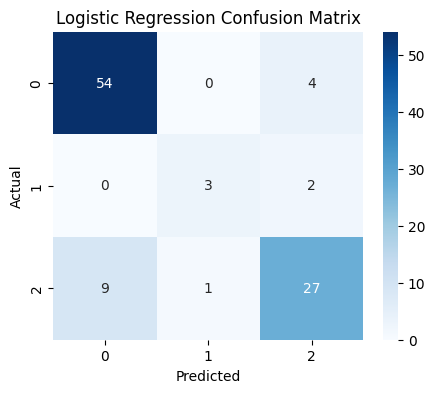

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.97
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      0.40      0.57         5
           2       0.93      1.00      0.96        37

    accuracy                           0.97       100
   macro avg       0.97      0.80      0.84       100
weighted avg       0.97      0.97      0.96       100



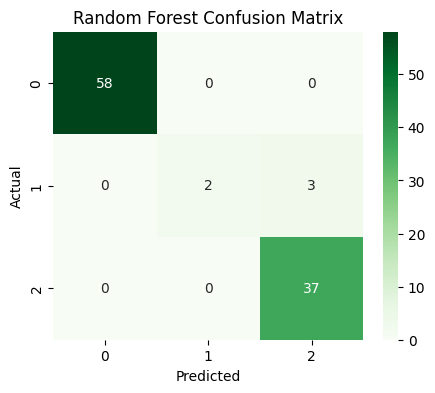

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00        37

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:03:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


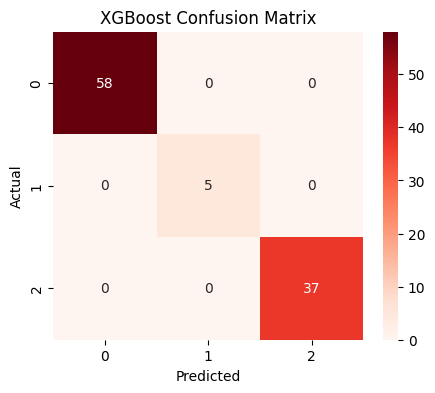

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("Model Comparison:")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Model Comparison:
Logistic Regression: 0.84
Random Forest: 0.97
XGBoost: 1.0
